# SPA V8 – Colab T4 Version
### Kombiniert aus:
- ✅ SPA V8 (Pheromone pro Layer, Dropout, Decay)
- ✅ Auto-Tau Regularisierung vom alten Colab Kernel
- ✅ T4 optimierte Einstellungen (grösseres Modell, mehr Steps)
- ✅ Tokens/Sekunde Messung (richtig eingebaut!)
- ✅ Checkpoint Speichern alle 1000 Steps

In [2]:
# GPU Check
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time

print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Verfügbar: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Verwende: {device}')

PyTorch Version: 2.10.0+cu128
CUDA Verfügbar: True
GPU Name: Tesla T4
VRAM: 15.6 GB
Verwende: cuda


In [3]:
# ===================== HELPER FUNCTIONS =====================

def _topk_gather(values, topk_indices):
    B, H, T, D = values.shape
    K = topk_indices.size(-1)
    b_idx = torch.arange(B, device=values.device)[:, None, None, None]
    h_idx = torch.arange(H, device=values.device)[None, :, None, None]
    t_idx = topk_indices[:, None, :, :].expand(B, H, T, K)
    return values[b_idx, h_idx, t_idx, :]

def sparse_attention_impl(q, k, topk_indices):
    gathered_k = _topk_gather(k, topk_indices)
    return (q.unsqueeze(3) * gathered_k).sum(dim=-1)

def sparse_value_aggregation_impl(attn, v, topk_indices):
    gathered_v = _topk_gather(v, topk_indices)
    return (attn.unsqueeze(-1) * gathered_v).sum(dim=-2)

def safe_topk_indices(scores, k):
    k = min(k, scores.size(-1))
    if k <= 0:
        return torch.zeros(*scores.shape[:-1], 1, dtype=torch.long, device=scores.device)
    return torch.topk(scores, k=k, dim=-1).indices


# ===================== AUTO-TAU (vom alten Colab Kernel) =====================

def tau_regularization_unweighted(model, target=50.0):
    """Berechnet die ungewichtete Tau-Regularisierung."""
    tau = model.current_tau()
    return ((tau - target) / 99.0).pow(2).mean()

def tau_reg_auto_weight(base_weight, ce_loss, reg_unweighted,
                        target_ratio=0.02,
                        min_factor=0.25,
                        max_factor=4.0):
    """Passt das Tau-Regularisierungsgewicht automatisch an.
    Ziel: Tau-Reg soll ~target_ratio des CE-Loss ausmachen."""
    if reg_unweighted.item() < 1e-8:
        return base_weight
    desired = target_ratio * ce_loss.item()
    current = base_weight * reg_unweighted.item()
    factor = desired / (current + 1e-8)
    factor = max(min_factor, min(max_factor, factor))
    return base_weight * factor


# ===================== PHEROMONE UPDATE =====================

def apply_pheromone_update(pheromone_layer, pheromone_decay, pheromone_alpha, attn, combined_tau_idx, T, n_heads):
    with torch.no_grad():
        pheromone = pheromone_layer[:, :T, :T]
        attn_mean = attn.mean(dim=0)
        idx = combined_tau_idx[0].unsqueeze(0).expand(n_heads, -1, -1)
        deposit = torch.zeros_like(pheromone)
        deposit.scatter_add_(dim=-1, index=idx, src=attn_mean)
        pheromone *= (1.0 - pheromone_decay)
        pheromone += deposit
        pheromone.clamp_(0.0, 5.0)


# ===================== SPA V8 MODELL =====================

class SPA_V8_Model(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=8, n_layers=6,
                 k=42, max_seq_len=512, local_k=12, explore_k=6,
                 tau_min=1.0, tau_max=100.0, tau_init=40.0,
                 dropout=0.1,
                 pheromone_decay=0.05):
        super().__init__()

        assert embed_dim % num_heads == 0, f"embed_dim ({embed_dim}) muss durch num_heads ({num_heads}) teilbar sein!"

        self.embed_dim = embed_dim
        self.n_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.k = k
        self.n_layers = n_layers
        self.max_seq_len = max_seq_len
        self.local_k = min(local_k, k)
        self.explore_k = max(0, min(explore_k, k - self.local_k))
        self.pheromone_decay = pheromone_decay
        self.pheromone_alpha = 0.15
        self.tau_min = tau_min
        self.tau_max = tau_max

        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(max_seq_len, embed_dim)

        # Pheromone pro Layer getrennt
        for i in range(n_layers):
            self.register_buffer(f'pheromone_{i}', torch.zeros(self.n_heads, max_seq_len, max_seq_len))

        # Tau Parameter (Log-Space für Stabilität)
        eps = 1e-4
        init_ratio = (tau_init - tau_min) / (tau_max - tau_min)
        init_ratio = min(max(init_ratio, eps), 1.0 - eps)
        self.log_tau = nn.Parameter(torch.full((1, 1, k), math.log(init_ratio / (1.0 - init_ratio))))

        self.global_router = nn.Linear(embed_dim, max_seq_len)

        self.dropout = nn.Dropout(dropout)
        self.emb_dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            nn.ModuleList([
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, 3 * embed_dim),
                nn.Linear(embed_dim, embed_dim),
                nn.LayerNorm(embed_dim),
                nn.Sequential(
                    nn.Linear(embed_dim, 4 * embed_dim),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(4 * embed_dim, embed_dim)
                )
            ]) for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def current_tau(self):
        return self.tau_min + (self.tau_max - self.tau_min) * torch.sigmoid(self.log_tau)

    def get_pheromone(self, layer_id):
        return getattr(self, f'pheromone_{layer_id}')

    def _build_sparse_indices(self, x):
        B, T, _ = x.shape
        device = x.device
        parts = []

        if self.local_k > 0:
            positions = torch.arange(T, device=device)
            query_pos = positions.view(1, T, 1)
            local_offsets = torch.arange(1, self.local_k + 1, device=device).view(1, 1, self.local_k)
            local_idx = (query_pos - local_offsets).clamp(min=0).expand(B, -1, -1)
            parts.append(local_idx)

        if self.k - self.local_k > 0:
            causal_mask = torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()
            router_logits = self.global_router(x)[:, :, :T]
            router_logits = router_logits.masked_fill(causal_mask, float('-inf'))

            gk = self.k - self.local_k
            learned_k = max(1, gk // 2)
            learned_idx = safe_topk_indices(router_logits, learned_k)
            global_parts = [learned_idx]

            if gk - learned_k > 0:
                random_scores = torch.rand(B, T, T, device=device)
                random_scores = random_scores.masked_fill(causal_mask, -1.0)
                explore_idx = safe_topk_indices(random_scores, gk - learned_k)
                global_parts.append(explore_idx)

            global_idx = torch.cat(global_parts, dim=-1)
            if global_idx.size(-1) > gk:
                global_idx = global_idx[..., :gk]
            elif global_idx.size(-1) < gk:
                pad = torch.zeros(B, T, gk - global_idx.size(-1), device=device, dtype=torch.long)
                global_idx = torch.cat([global_idx, pad], dim=-1)
            parts.append(global_idx)

        combined = torch.cat(parts, dim=-1) if len(parts) > 1 else parts[0]
        return combined.long()

    def forward(self, idx):
        B, T = idx.shape
        device = idx.device

        x = self.token_emb(idx) + self.pos_emb(torch.arange(T, device=device))
        x = self.emb_dropout(x)

        tau_base = self.current_tau()
        tau_scale = (40.0 / (tau_base + 1e-8)).clamp(0.3, 3.5)

        for layer_id, (ln1, qkv_l, proj, ln2, mlp) in enumerate(self.layers):
            pheromone_buf = self.get_pheromone(layer_id)
            combined_tau_idx = self._build_sparse_indices(x)  # pro Layer

            h = ln1(x)
            qkv = qkv_l(h).reshape(B, T, 3, self.n_heads, self.head_dim)
            q = qkv[:, :, 0].transpose(1, 2).contiguous()
            k = qkv[:, :, 1].transpose(1, 2).contiguous()
            v = qkv[:, :, 2].transpose(1, 2).contiguous()

            raw_logits = sparse_attention_impl(q, k, combined_tau_idx) * (self.head_dim ** -0.5)

            pheromone = pheromone_buf[:, :T, :T]
            pheromone_bias = pheromone.unsqueeze(0).expand(B, -1, -1, -1)
            gathered_pheromone = torch.gather(
                pheromone_bias, dim=-1,
                index=combined_tau_idx.unsqueeze(1).expand(B, self.n_heads, T, -1)
            )

            logits = raw_logits + self.pheromone_alpha * gathered_pheromone
            logits = logits * tau_scale.unsqueeze(1)

            attn = F.softmax(logits, dim=-1)
            attn = self.dropout(attn)

            apply_pheromone_update(
                pheromone_buf, self.pheromone_decay, self.pheromone_alpha,
                attn, combined_tau_idx, T, self.n_heads
            )

            out = sparse_value_aggregation_impl(attn, v, combined_tau_idx)
            x = x + self.dropout(proj(out.transpose(1, 2).reshape(B, T, self.embed_dim)))
            x = x + mlp(ln2(x))

        return self.head(self.ln_f(x)), tau_base, combined_tau_idx

print('SPA V8 Modell bereit!')

SPA V8 Modell bereit!


In [4]:
# Dataset laden
import requests

url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
r = requests.get(url)
with open('input.txt', 'w', encoding='utf-8') as f:
    f.write(r.text)

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
VOCAB_SIZE = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
print(f'Vocab Size: {VOCAB_SIZE} | Dataset: {len(data)} Zeichen')

Vocab Size: 65 | Dataset: 1115394 Zeichen


In [5]:
# ===================== MODELL KONFIGURATION =====================
# T4 hat 16GB VRAM → grösseres Modell möglich!

model = SPA_V8_Model(
    vocab_size=VOCAB_SIZE,
    embed_dim=384,       # T4: grösser als GTX 1080!
    num_heads=8,         # 384 / 8 = 48 head_dim
    n_layers=6,
    k=18,
    max_seq_len=512,
    local_k=12,
    explore_k=6,
    tau_init=40.0,
    dropout=0.1,
    pheromone_decay=0.05
).to(device)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Modellparameter: {total_params:.2f}M')
if torch.cuda.is_available():
    print(f'GPU Speicher nach Modell: {torch.cuda.memory_allocated() / 1e6:.1f} MB')

Modellparameter: 11.09M
GPU Speicher nach Modell: 94.7 MB


In [5]:
# ===================== TRAINING SETUP =====================

BATCH_SIZE = 32          # T4 kann mehr als GTX 1080!
BLOCK_SIZE = 256
TRAIN_STEPS = 10000
CHECKPOINT_EVERY = 1000  # alle 1000 Steps speichern

# Auto-Tau Parameter (vom alten Colab Kernel)
TAU_TARGET = 50.0
TAU_REG_WEIGHT = 1e-4
TAU_REG_WARMUP_STEPS = 2000
AUTO_TAU_TUNE = True
TAU_REG_TARGET_RATIO = 0.02
TAU_REG_AUTO_MIN_FACTOR = 0.25
TAU_REG_AUTO_MAX_FACTOR = 4.0
TAU_REG_EMA_BETA = 0.95
tau_reg_weight_ema = TAU_REG_WEIGHT

# Train/Val Split
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - BLOCK_SIZE, (BATCH_SIZE,))
    xb = torch.stack([d[j:j+BLOCK_SIZE] for j in ix]).to(device)
    yb = torch.stack([d[j+1:j+BLOCK_SIZE+1] for j in ix]).to(device)
    return xb, yb

@torch.no_grad()
def estimate_val_loss(eval_iters=50):
    model.eval()
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        xb, yb = get_batch('val')
        logits, _, _ = model(xb)
        losses[k] = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1)).item()
    model.train()
    return losses.mean().item()

# Optimizer mit getrennten Lernraten
optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'log_tau' not in n], 'lr': 3e-4},
    {'params': model.log_tau, 'lr': 1e-3}
], weight_decay=0.05)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TRAIN_STEPS)

print(f'Training Setup bereit: {TRAIN_STEPS} Steps, Batch={BATCH_SIZE}')

Training Setup bereit: 10000 Steps, Batch=32


In [6]:
# ===================== TRAINING LOOP =====================
import math

model.train()
metrics = {'step': [], 'train_loss': [], 'val_loss': [], 'perplexity': [], 'tau': []}

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

training_start = time.time()
step_start = time.time()
tokens_since_last = 0

print(f'Starte SPA V8 Training ({TRAIN_STEPS} Steps, Batch={BATCH_SIZE})...\n')

for step in range(TRAIN_STEPS + 1):
    xb, yb = get_batch('train')
    tokens_since_last += BATCH_SIZE * BLOCK_SIZE

    logits, tau_vals, _ = model(xb)
    ce_loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))

    # Auto-Tau Regularisierung
    tau_reg_raw = tau_regularization_unweighted(model, target=TAU_TARGET)
    tau_reg_weight_auto = tau_reg_auto_weight(
        base_weight=TAU_REG_WEIGHT,
        ce_loss=ce_loss,
        reg_unweighted=tau_reg_raw,
        target_ratio=TAU_REG_TARGET_RATIO,
        min_factor=TAU_REG_AUTO_MIN_FACTOR,
        max_factor=TAU_REG_AUTO_MAX_FACTOR,
    ) if AUTO_TAU_TUNE else TAU_REG_WEIGHT

    tau_reg_weight_ema = TAU_REG_EMA_BETA * tau_reg_weight_ema + (1.0 - TAU_REG_EMA_BETA) * tau_reg_weight_auto
    tau_reg_weight = min(1.0, step / max(1, TAU_REG_WARMUP_STEPS)) * tau_reg_weight_ema
    tau_reg = tau_reg_weight * tau_reg_raw
    loss = ce_loss + tau_reg

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    if step % 500 == 0:
        val_loss = estimate_val_loss()
        ppl = math.exp(val_loss)
        current_tau = model.current_tau().mean().item()
        elapsed = time.time() - training_start

        # Tokens pro Sekunde
        tok_per_sec = tokens_since_last / (time.time() - step_start + 1e-8)
        step_start = time.time()
        tokens_since_last = 0

        metrics['step'].append(step)
        metrics['train_loss'].append(ce_loss.item())
        metrics['val_loss'].append(val_loss)
        metrics['perplexity'].append(ppl)
        metrics['tau'].append(current_tau)

        print(f'Step {step:5d} | Loss: {ce_loss.item():.4f} | Val: {val_loss:.4f} | '
              f'PPL: {ppl:.2f} | Tau: {current_tau:.1f} | '
              f'LR: {scheduler.get_last_lr()[0]:.2e} | '
              f'Tok/s: {tok_per_sec:.0f} | Zeit: {elapsed:.0f}s')

    # Checkpoint alle 1000 Steps
    if step % CHECKPOINT_EVERY == 0 and step > 0:
        from safetensors.torch import save_file
        path = f'spa_v8_checkpoint_step{step}.safetensors'
        save_file(model.state_dict(), path)
        print(f'  → Checkpoint gespeichert: {path}')

# Finales Ergebnis
total_time = time.time() - training_start
gpu_mem = torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else 0

print(f'\n{"="*55}')
print(f'SPA V8 FINAL ERGEBNISSE')
print(f'{"="*55}')
print(f'Final Val Loss:       {metrics["val_loss"][-1]:.4f}')
print(f'Final Val Perplexity: {metrics["perplexity"][-1]:.2f}')
print(f'Trainingszeit:        {total_time/60:.1f} Minuten')
print(f'GPU Peak Memory:      {gpu_mem:.1f} MB')
print(f'{"="*55}')

Starte SPA V8 Training (10000 Steps, Batch=32)...

Step     0 | Loss: 4.3181 | Val: 3.6807 | PPL: 39.67 | Tau: 40.0 | LR: 3.00e-04 | Tok/s: 539 | Zeit: 15s
Step   500 | Loss: 1.6393 | Val: 1.7050 | PPL: 5.50 | Tau: 47.8 | LR: 2.98e-04 | Tok/s: 10227 | Zeit: 416s
Step  1000 | Loss: 1.3984 | Val: 1.5315 | PPL: 4.63 | Tau: 51.0 | LR: 2.93e-04 | Tok/s: 9444 | Zeit: 849s
  → Checkpoint gespeichert: spa_v8_checkpoint_step1000.safetensors
Step  1500 | Loss: 1.3154 | Val: 1.4654 | PPL: 4.33 | Tau: 53.1 | LR: 2.84e-04 | Tok/s: 9436 | Zeit: 1284s
Step  2000 | Loss: 1.2109 | Val: 1.4196 | PPL: 4.14 | Tau: 54.9 | LR: 2.71e-04 | Tok/s: 9434 | Zeit: 1718s
  → Checkpoint gespeichert: spa_v8_checkpoint_step2000.safetensors
Step  2500 | Loss: 1.1839 | Val: 1.3968 | PPL: 4.04 | Tau: 56.5 | LR: 2.56e-04 | Tok/s: 9435 | Zeit: 2152s
Step  3000 | Loss: 1.1926 | Val: 1.3971 | PPL: 4.04 | Tau: 57.8 | LR: 2.38e-04 | Tok/s: 9448 | Zeit: 2585s
  → Checkpoint gespeichert: spa_v8_checkpoint_step3000.safetensors
St

KeyboardInterrupt: 

In [ ]:
# Finales Modell speichern
from safetensors.torch import save_file

save_file(model.state_dict(), 'spa_v8_final.safetensors')
print('Modell gespeichert: spa_v8_final.safetensors')

# Optional: auf Google Drive speichern
# from google.colab import drive
# drive.mount('/content/drive')
# save_file(model.state_dict(), '/content/drive/MyDrive/spa_v8_final.safetensors')

In [10]:
from safetensors.torch import load_model

model_loaded = SPA_V8_Model(
    vocab_size=VOCAB_SIZE,
    embed_dim=384,
    num_heads=8,
    n_layers=6,
    k=48,
    max_seq_len=512,
    local_k=12,
    explore_k=6,
    tau_init=40.0,
    dropout=0.1,
    pheromone_decay=0.05
)
load_model(model_loaded, 'spa_v8_checkpoint_step4000.safetensors')
model_loaded.to(device)
print("SPA V8 erfolgreich geladen!")

SPA V8 erfolgreich geladen!


In [7]:
import torch

# Full Checkpoint erstellen
checkpoint = {
    'step': 5000,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'metrics': metrics,  # Damit deine Graphen morgen weiterlaufen
    'tau_current': model.tau.item() if hasattr(model, 'tau') else 59.7
}

# In Colab speichern
torch.save(checkpoint, 'spa_v8_RESTART_5000.pth')

In [27]:
# 1. ARCHITEKTUR DEFINIEREN (muss exakt wie heute sein!)
# model = SPA_V8_Model(embed_dim=384, ...)

# 2. CHECKPOINT LADEN
checkpoint = torch.load('spa_v8_RESTART_5000.pth', map_location=device)

# 3. GEWICHTE UND TAU WIEDERHERSTELLEN
model.load_state_dict(checkpoint['model_state_dict'])

# Falls Tau eine Variable im Modell ist:
if 'tau_current' in checkpoint:
    model.tau = torch.tensor(checkpoint['tau_current']).to(device)
elif 'tau' in checkpoint:
    model.tau = torch.tensor(checkpoint['tau']).to(device)

# 4. OPTIMIZER UND METRIKEN (nur wenn du weiter trainieren willst)
#optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
metrics = checkpoint.get('metrics', {'step': [], 'train_loss': [], 'val_loss': [], 'perplexity': [], 'tau': []})
start_step = checkpoint.get('step', 5000)

print(f"🚀 Erfolg! Modell bei Step {start_step} mit Tau {model.tau.item():.2f} geladen.")


🚀 Erfolg! Modell bei Step 5000 mit Tau 59.70 geladen.


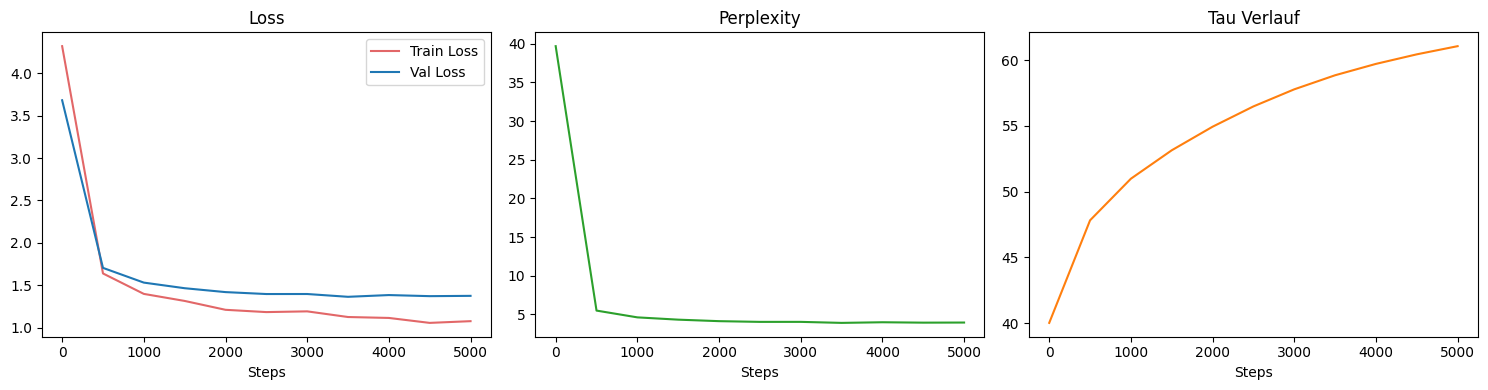

In [28]:
6# ===================== TRAINING KURVE =====================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(metrics['step'], metrics['train_loss'], label='Train Loss', color='tab:red', alpha=0.7)
axes[0].plot(metrics['step'], metrics['val_loss'], label='Val Loss', color='tab:blue')
axes[0].set_title('Loss')
axes[0].set_xlabel('Steps')
axes[0].legend()

axes[1].plot(metrics['step'], metrics['perplexity'], color='tab:green')
axes[1].set_title('Perplexity')
axes[1].set_xlabel('Steps')

axes[2].plot(metrics['step'], metrics['tau'], color='tab:orange')
axes[2].set_title('Tau Verlauf')
axes[2].set_xlabel('Steps')

plt.tight_layout()
plt.show()

In [31]:
import torch

# ===================== TEXT GENERIERUNG =====================

def top_p_sampling(logits, p=0.9):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
    sorted_indices_to_remove = cumulative_probs > p
    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
    sorted_indices_to_remove[..., 0] = 0
    indices_to_remove = sorted_indices[sorted_indices_to_remove]
    logits[indices_to_remove] = float('-inf')
    return logits

model.eval()

start_context = 'ROMEO: To '
GEN_LENGTH = 600
TEMPERATURE = 0.65
TOP_P = 0.9
REPETITION_PENALTY = 1.3
PENALTY_WINDOW = 0

# T_CTX = max_seq_len (richtig eingebaut!)
T_CTX = model.max_seq_len

# --- Fehlerdiagnose und potenzielle Behebung für "CUDA error: device-side assert triggered" ---
# Dieser Fehler tritt oft auf, wenn der GPU-Zustand durch eine vorherige
# Unterbrechung (z.B. KeyboardInterrupt im Training) inkonsistent wurde.
# Die Fehlermeldung kann asynchron von einem früheren Vorgang stammen.
#
# Empfohlene Lösung: Starten Sie die Colab-Laufzeit (Menüpunkt 'Laufzeit' -> 'Laufzeit neu starten')
# neu und führen Sie danach alle relevanten Zellen erneut aus.
#
# Ein Versuch, den GPU-Cache zu leeren, kann manchmal helfen, ist aber keine Garantie:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
# -------------------------------------------------------------------------------------------------

idx = torch.tensor(encode(start_context), dtype=torch.long).unsqueeze(0).to(device)

gen_start = time.time()
print(f'Generiere {GEN_LENGTH} Tokens (Temp: {TEMPERATURE}, T_CTX: {T_CTX})...')

with torch.no_grad():
    for i in range(GEN_LENGTH):
        idx_cond = idx[:, -T_CTX:]  # Kontext auf T_CTX begrenzen
        logits, _, _ = model(idx_cond)
        logits = logits[0, -1, :] / TEMPERATURE

        recent_tokens = set(idx[0, -PENALTY_WINDOW:].tolist())
        for char_token in recent_tokens:
            if logits[char_token] > 0:
                logits[char_token] /= REPETITION_PENALTY
            else:
                logits[char_token] *= REPETITION_PENALTY

        filtered_logits = top_p_sampling(logits, p=TOP_P)
        probs = F.softmax(filtered_logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_idx.unsqueeze(0)), dim=1)

gen_time = time.time() - gen_start
print(f'Generierungszeit: {gen_time:.1f}s | Tokens/Sekunde: {GEN_LENGTH/gen_time:.1f}')
print('\n--- Ergebnis SPA V8 (T4) ---\n')
print(decode(idx[0].tolist()))

Generiere 600 Tokens (Temp: 0.2, T_CTX: 512)...
Generierungszeit: 11.8s | Tokens/Sekunde: 51.0

--- Ergebnis SPA V8 (T4) ---

ROMEO: To GHAMNGBROKE:
What, wilt thou never be so far a company?

QUEEN ELIZABETH:
Shall I be dead.

DUCHESS OF YORK:
Why, then I was great and weeping to the world;
Which then we shall be the world with the field
Of the good father's park of the world and the dead!

JULIET:
What says the counts the prince of the death.

Provost:
I think thee to thy brother Richard, and the world against the state,
That we shall be the prophets of the world.

KING RICHARD III:
What doth you will see the fight of a woman,
And the dead man of the state was the
worst of the people of the power of the book.

CLARENCE:
Then


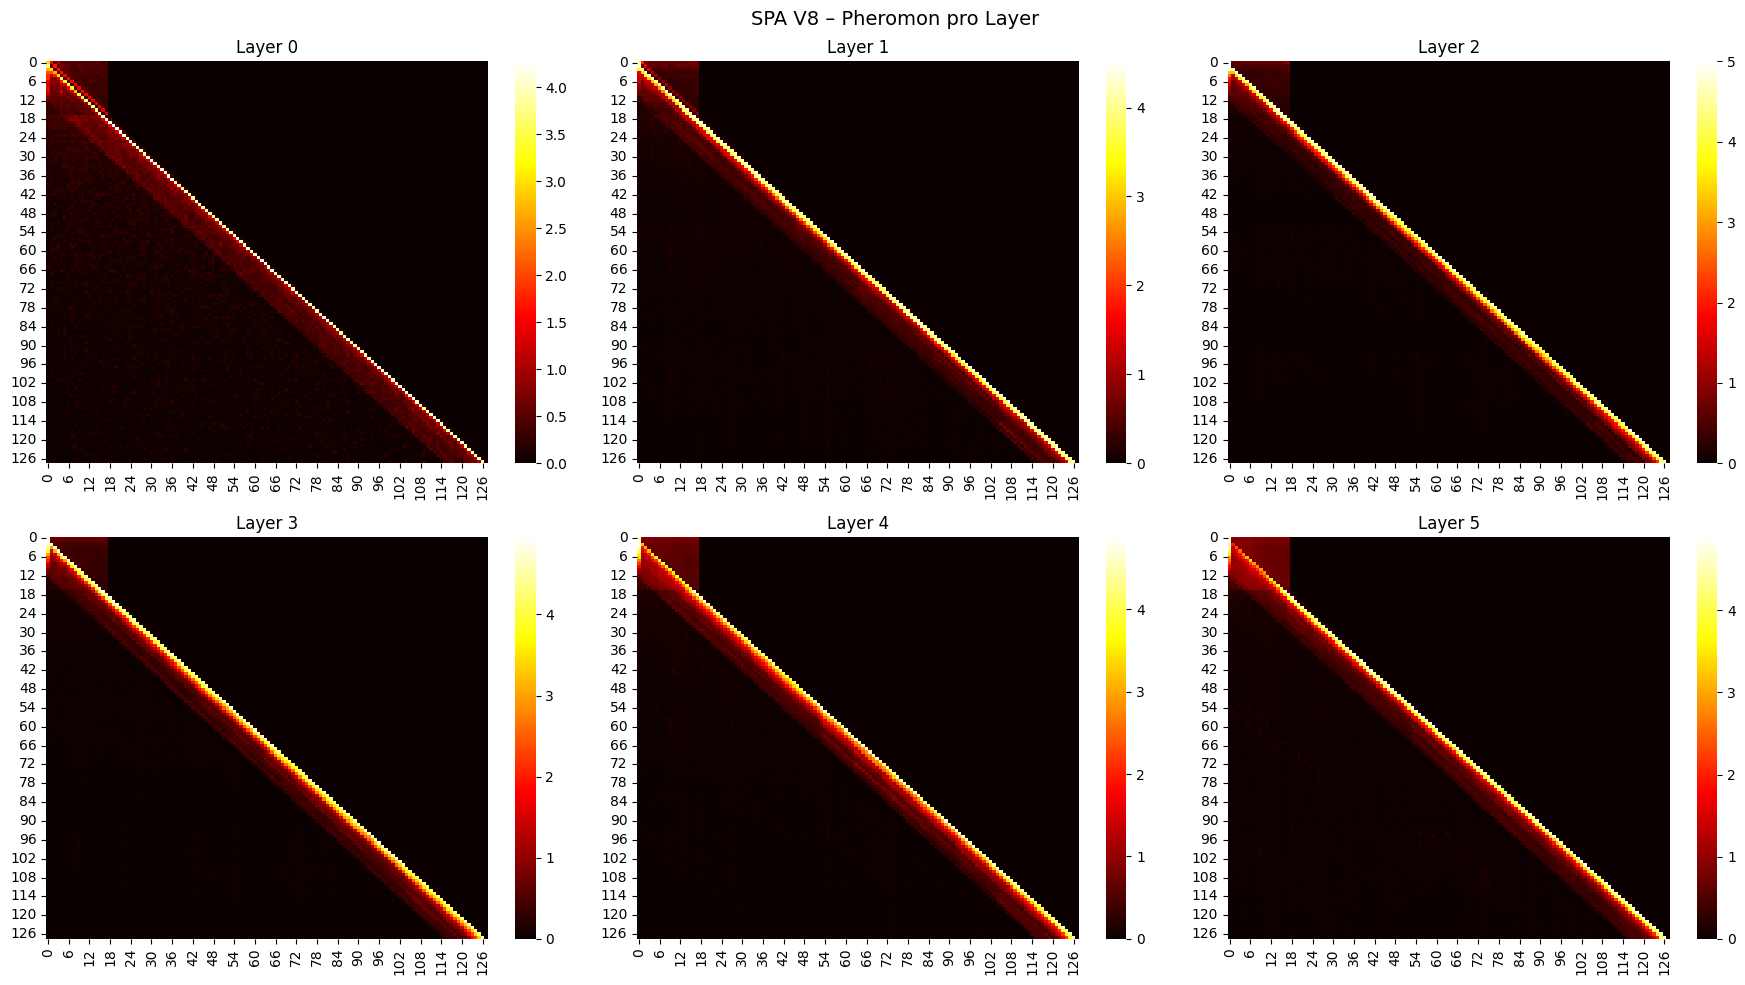

In [30]:
# ===================== PHEROMONE VISUALISIERUNG =====================
!pip install seaborn -q

import seaborn as sns
import matplotlib.pyplot as plt

def plot_all_pheromone_layers(model, seq_len=128):
    """Alle Layer-Pheromone nebeneinander."""
    n = model.n_layers
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flatten()

    for i in range(n):
        phero = model.get_pheromone(i).detach().cpu().numpy()
        avg = phero.mean(axis=0)[:seq_len, :seq_len]
        sns.heatmap(avg, cmap='hot', ax=axes[i], cbar=True)
        axes[i].set_title(f'Layer {i}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')

    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('SPA V8 – Pheromon pro Layer', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_all_pheromone_layers(model, seq_len=128)